In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
PLOT_DIR   = '/content/drive/MyDrive/insurance_fraud/plots/'

import os
os.makedirs(PLOT_DIR, exist_ok=True)

df = pd.read_parquet(OUTPUT_DIR + 'train_provider_merged.parquet')
fraud     = df[df['fraud_label'] == 1]
non_fraud = df[df['fraud_label'] == 0]
print(f'Loaded: {df.shape}')

Mounted at /content/drive
Loaded: (5410, 34)


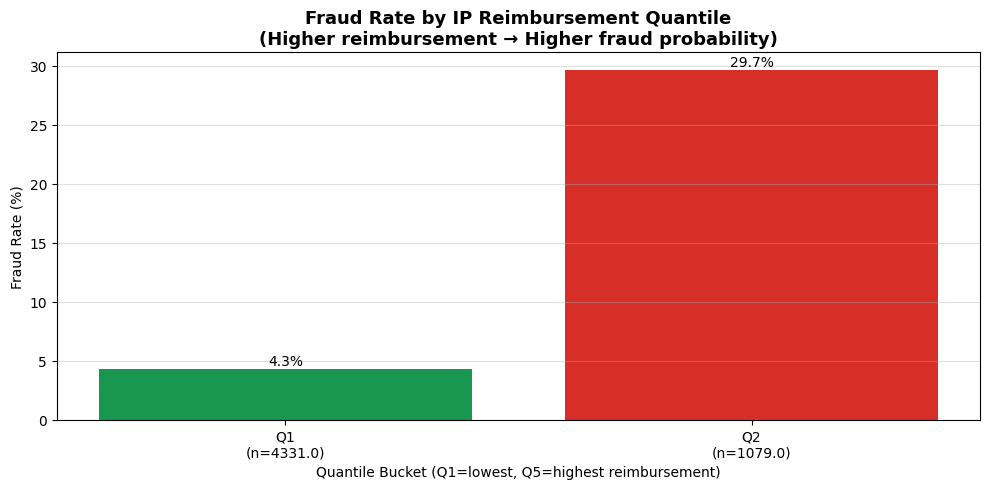

Saved plot_fraud_rate_by_quantile.png


In [2]:
# Plot: Fraud Rate by Reimbursement Quantile
# This is the most important plot — shows fraud rate rises with reimbursement
fig, ax = plt.subplots(figsize=(10, 5))

col = 'ip_avg_reimbursement'
if col in df.columns:
    df['_bucket'] = pd.qcut(df[col], q=5, duplicates='drop', labels=False)
    bucket_fraud  = df.groupby('_bucket')['fraud_label'].agg(['mean','count']).reset_index()

    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(bucket_fraud)))
    bars = ax.bar(range(len(bucket_fraud)), bucket_fraud['mean']*100, color=colors)
    ax.set_xticks(range(len(bucket_fraud)))
    ax.set_xticklabels([f'Q{i+1}\n(n={r["count"]})' for i, r in bucket_fraud.iterrows()])
    ax.set_title('Fraud Rate by IP Reimbursement Quantile\n(Higher reimbursement → Higher fraud probability)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel('Quantile Bucket (Q1=lowest, Q5=highest reimbursement)')
    ax.yaxis.grid(True, alpha=0.4)

    for bar, val in zip(bars, bucket_fraud['mean']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val*100:.1f}%', ha='center', fontsize=10)

    df.drop(columns=['_bucket'], inplace=True)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'plot_fraud_rate_by_quantile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_fraud_rate_by_quantile.png')

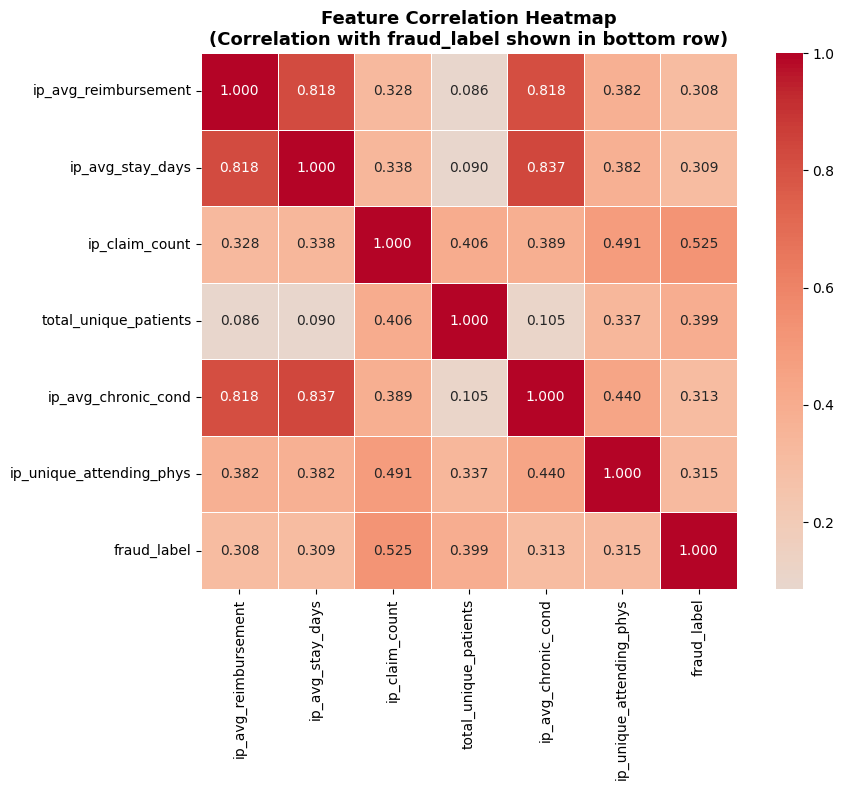

Saved plot_correlation_heatmap.png

Top correlations with fraud_label:
  ip_claim_count                           r = +0.525
  total_unique_patients                    r = +0.399
  ip_unique_attending_phys                 r = +0.315
  ip_avg_chronic_cond                      r = +0.313
  ip_avg_stay_days                         r = +0.309
  ip_avg_reimbursement                     r = +0.308


In [3]:
# Correlation Heatmap
numeric_cols = ['ip_avg_reimbursement', 'ip_avg_stay_days', 'ip_claim_count',
                'total_unique_patients', 'ip_avg_chronic_cond',
                'ip_unique_attending_phys', 'fraud_label']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
ax.set_title('Feature Correlation Heatmap\n(Correlation with fraud_label shown in bottom row)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR + 'plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_correlation_heatmap.png')

# Print top correlations with fraud_label
print('\nTop correlations with fraud_label:')
fraud_corr = corr['fraud_label'].drop('fraud_label').abs().sort_values(ascending=False)
for col, val in fraud_corr.head(6).items():
    print(f'  {col:<40} r = {corr.loc[col,"fraud_label"]:+.3f}')